In [ ]:
!pip install datasets seqeval pytorch-crf -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset, DatasetDict
from torchcrf import CRF
from seqeval.metrics import f1_score
from seqeval.metrics import classification_report as seqeval_report
from collections import Counter
from tqdm import tqdm

In [ ]:
print("Loading dan Splitting Dataset (WikiNER)...")

dataset_raw = load_dataset("mnaguib/WikiNER", "en")

# Memecah data menjadi Train, Val, Test
train_test_split = dataset_raw["train"].train_test_split(test_size=0.2, seed=42)
val_test_split = train_test_split["test"].train_test_split(test_size=0.5, seed=42)

dataset = DatasetDict({
    "train": train_test_split["train"],
    "validation": val_test_split["train"],
    "test": val_test_split["test"]
})

# Label standar WikiNER
label_list = ["O", "LOC", "PER", "MISC", "ORG"]
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}
NUM_LABELS = len(label_list)

print("Berhasil! Ukuran dataset:", dataset)

Loading dan Splitting Dataset (WikiNER)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.95k [00:00<?, ?B/s]

data/en/train.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

data/en/test.parquet:   0%|          | 0.00/1.57M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/129376 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14398 [00:00<?, ? examples/s]

Berhasil! Ukuran dataset: DatasetDict({
    train: Dataset({
        features: ['id', 'words', 'ner_tags'],
        num_rows: 103500
    })
    validation: Dataset({
        features: ['id', 'words', 'ner_tags'],
        num_rows: 12938
    })
    test: Dataset({
        features: ['id', 'words', 'ner_tags'],
        num_rows: 12938
    })
})


In [ ]:
print("Membangun Vocabulary...")
word_counter = Counter()

for sample in dataset["train"]:
    words = sample["words"]
    word_counter.update(words)

#PAD buat ngisi ruang kosong, UNK buat kata yang nggak ada di kamus
vocab = {"<PAD>": 0, "<UNK>": 1}
for word in word_counter:
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Membangun Vocabulary...
Vocabulary size: 101975


In [ ]:
MAX_LEN = 128
BATCH_SIZE = 16
EMBEDDING_DIM = 256
HIDDEN_DIM = 256
EPOCHS = 3

def encode_tokens(tokens):
    return [vocab.get(token, vocab["<UNK>"]) for token in tokens]

class NERDataset(Dataset):
    def __init__(self, split):
        self.data = split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        tokens = item["words"]
        labels = item["ner_tags"]

        input_ids = encode_tokens(tokens)

        # Padding / Truncation
        if len(input_ids) > MAX_LEN:
            input_ids = input_ids[:MAX_LEN]
            labels = labels[:MAX_LEN]

        attention_mask = [1] * len(input_ids)
        pad_len = MAX_LEN - len(input_ids)

        input_ids += [0] * pad_len
        labels += [0] * pad_len
        attention_mask += [0] * pad_len

        return {
            "input_ids": torch.tensor(input_ids),
            "labels": torch.tensor(labels),
            "attention_mask": torch.tensor(attention_mask)
        }

train_dataset = NERDataset(dataset["train"])
valid_dataset = NERDataset(dataset["validation"])
test_dataset = NERDataset(dataset["test"])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
print("DataLoader siap!")

DataLoader siap!


In [ ]:
class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_labels):
        super(BiLSTM_CRF, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0) #Ngubah ID kata jadi vektor (embedding)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim // 2, num_layers=1, bidirectional=True, batch_first=True) #baca kalimat bolak-balik dari kiri-kanan & kanan-kiri (Bidirectional LSTM)
        self.fc = nn.Linear(hidden_dim, num_labels) #nebak probabilitas per-kata masuk kelas label yang mana (PER, LOC, dll)
        self.crf = CRF(num_labels, batch_first=True)

    def forward(self, input_ids, attention_mask, labels=None):
        embeddings = self.embedding(input_ids)
        lstm_out, _ = self.lstm(embeddings)
        emissions = self.fc(lstm_out)
        mask = attention_mask.bool()

        if labels is not None:
            loss = -self.crf(emissions, labels, mask=mask, reduction='mean')
            return loss
        else:
            predictions = self.crf.decode(emissions, mask=mask)
            return predictions

print("Arsitektur model siap!")

Arsitektur model siap!


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BiLSTM_CRF(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, NUM_LABELS).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Model dijalankan menggunakan: {DEVICE}")

Model dijalankan menggunakan: cuda


In [ ]:
print("Mulai Training & Validasi...")

# Bikin 2 list untuk nampung loss training dan loss validasi
training_loss_history = []
validation_loss_history = []

for epoch in range(EPOCHS):
    # ==========================================
    # FASE 1: TRAINING (Model Belajar)
    # ==========================================
    model.train()
    total_train_loss = 0
    loop = tqdm(train_loader, leave=False)

    for batch in loop:
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        optimizer.zero_grad()
        loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        loop.set_description(f"Epoch {epoch+1} (Train)")
        loop.set_postfix(loss=loss.item())

    # Rata-rata Training loss di epoch ini
    epoch_train_loss = total_train_loss / len(train_loader)
    training_loss_history.append(epoch_train_loss)

    # ==========================================
    # FASE 2: VALIDATION (Model Ujian Tiap Epoch)
    # ==========================================
    model.eval() # PENTING: Ubah mode jadi evaluasi
    total_valid_loss = 0

    # PENTING: Matikan perhitungan gradien biar hemat memori
    with torch.no_grad():
        for batch in valid_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)

            # Hitung loss untuk data validasi
            val_loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_valid_loss += val_loss.item()

    # Rata-rata Validation loss di epoch ini
    epoch_valid_loss = total_valid_loss / len(valid_loader)
    validation_loss_history.append(epoch_valid_loss)

    # Print hasilnya sejajar biar gampang dipantau
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Valid Loss: {epoch_valid_loss:.4f}")

Mulai Training & Validasi...


Epoch 1/3 | Train Loss: 2.7057 | Valid Loss: 1.4692


Epoch 2/3 | Train Loss: 0.9390 | Valid Loss: 1.2524


Epoch 3/3 | Train Loss: 0.4774 | Valid Loss: 1.3851


In [ ]:
print("Evaluasi Model di Test Set...")
model.eval()
true_labels = []
pred_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        # Hasil prediksi dari CRF udah OTOMATIS membuang padding
        predictions = model(input_ids=input_ids, attention_mask=attention_mask)

        for i in range(len(predictions)):
            pred_seq = predictions[i]
            true_seq = labels[i].cpu().numpy()

            # Potong true_seq agar panjangnya sama dengan pred_seq (membuang padding secara otomatis)
            true_seq_unpadded = true_seq[:len(pred_seq)]

            # Konversi ID angka kembali menjadi string label (seperti "B-PER", "O", dll)
            temp_true = [id2label[t] for t in true_seq_unpadded]
            temp_pred = [id2label[p] for p in pred_seq]

            true_labels.append(temp_true)
            pred_labels.append(temp_pred)

print("\n================ FINAL REPORT ================")
print(f"F1 SCORE: {f1_score(true_labels, pred_labels):.4f}")
print("\nCLASSIFICATION REPORT:")
print(seqeval_report(true_labels, pred_labels))

Evaluasi Model di Test Set...


100%|██████████| 809/809 [00:20<00:00, 39.20it/s]
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: LOC seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: PER seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ORG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))



================ FINAL REPORT ================
F1 SCORE: 0.8650

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          ER       0.85      0.92      0.88      8739
          OC       0.81      0.88      0.84      7468

   micro avg       0.83      0.90      0.86     16207
   macro avg       0.83      0.90      0.86     16207
weighted avg       0.83      0.90      0.86     16207



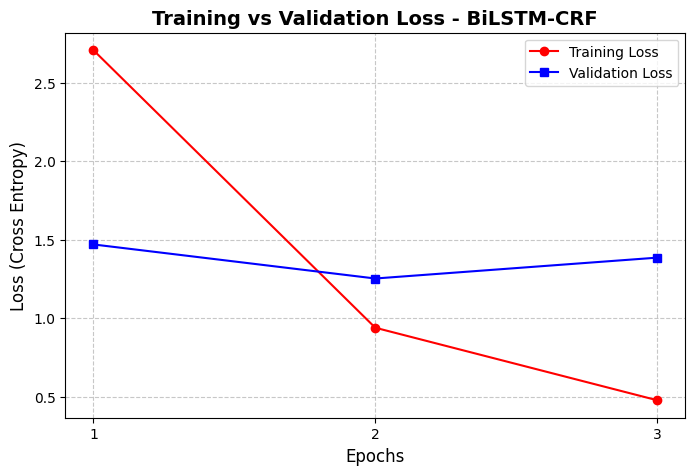

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# Plot 2 garis: Training (Merah) dan Validation (Biru)
plt.plot(range(1, EPOCHS + 1), training_loss_history, marker='o', linestyle='-', color='red', label='Training Loss')
plt.plot(range(1, EPOCHS + 1), validation_loss_history, marker='s', linestyle='-', color='blue', label='Validation Loss')

# Bikin tampilannya rapi
plt.title('Training vs Validation Loss - BiLSTM-CRF', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Cross Entropy)', fontsize=12)
plt.xticks(range(1, EPOCHS + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Tampilkan grafik
plt.show()

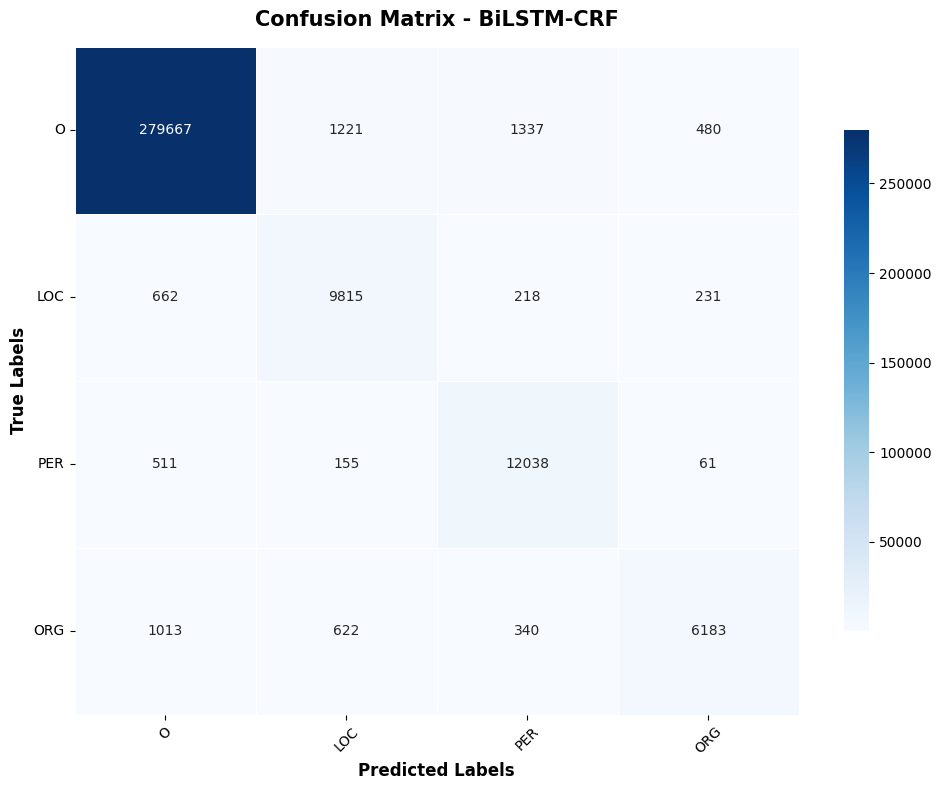

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Leburkan (Flatten) label asli dan prediksi jadi 1 dimensi
flat_true = [label for seq in true_labels for label in seq]
flat_pred = [label for seq in pred_labels for label in seq]

# 2. Ambil daftar label unik yang muncul biar urutannya rapi
labels_in_test = list(set(flat_true + flat_pred))
# Urutkan berdasarkan label_list standar lu
labels_in_test = [l for l in label_list if l in labels_in_test]

# 3. Hitung Confusion Matrix
cm = confusion_matrix(flat_true, flat_pred, labels=labels_in_test)

# 4. Gambar Heatmap Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_in_test, yticklabels=labels_in_test,
            linewidths=.5, cbar_kws={"shrink": .75})

# Dekorasi biar cakep masuk Laporan
plt.title("Confusion Matrix - BiLSTM-CRF", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Predicted Labels", fontsize=12, fontweight='bold')
plt.ylabel("True Labels", fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Tampilkan grafik
plt.show()

In [ ]:
import torch
import json
import os
from google.colab import drive

# =============================================================
#   SAVE MODEL PURE PYTORCH & VOCAB KE GOOGLE DRIVE
# =============================================================
print("Menyimpan model ke penyimpanan Colab...")

# 1. Save Bobot Model PyTorch (bentuknya file .pth)
torch.save(model.state_dict(), 'bilstm_crf_model.pth')

# 2. Save Vocabulary (INI PENTING BANGET!)
# Kalau vocab nggak di-save, Streamlit kamu nanti nggak bisa baca kata-kata
with open('vocab.json', 'w') as f:
    json.dump(vocab, f)

print("Membuka akses ke Google Drive...")
# 3. Buka jalur ke Google Drive
drive.mount('/content/drive')

# Bikin folder khusus di Drive biar rapi (opsional)
os.makedirs('/content/drive/MyDrive/BiLSTM_NER_Final', exist_ok=True)

print("Memindahkan file ke Google Drive...")
# 4. Lempar kedua file tersebut ke Google Drive
!cp ./bilstm_crf_model.pth /content/drive/MyDrive/BiLSTM_NER_Final/bilstm_crf_model.pth
!cp ./vocab.json /content/drive/MyDrive/BiLSTM_NER_Final/vocab.json

print("AMAN! Model dan Vocab sukses diamankan ke Google Drive! 🎉")

Menyimpan model ke penyimpanan Colab...
Membuka akses ke Google Drive...


ValueError: mount failed